# Brain Tumor Segmentation

In [609]:
# Needed Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from fastai.vision.all import *
import SimpleITK as sitk
import shutil
from tqdm import tqdm
import nibabel as nib
from fastai.medical.imaging import *
import torch

## Data Exploring

Data is taken from Cancer Archiv Database. 

The ReMind Collection was choosen. 
https://www.cancerimagingarchive.net/collection/remind/

### Metadata and Patients Data

In [610]:
# read csv file
metadata = pd.read_csv('data/data_orig/ReMIND/metadata.csv', header=0 , sep=',', index_col=False)

metadata.head()

,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,Number of ?,File Size,File Location,Download Timestamp
0,1.3.6.1.4.1.14519.5.2.1.134061671453609869875210365239292226592,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-001,1.3.6.1.4.1.14519.5.2.1.207544490797667703011829289839681390478,Intraop,12-25-1982,2DAXT2BLADE,Unknown manufacturer,MR,MR Image Storage,1.2.840.10008.5.1.4.1.1.4,70,9,33 MB,./ReMIND/ReMIND-001/12-25-1982-NA-Intraop-90478/4.000000-2DAXT2BLADE-26592,2023-12-11T17:25:33.022
1,1.3.6.1.4.1.14519.5.2.1.180075680557505954475077325083212188762,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-001,1.3.6.1.4.1.14519.5.2.1.207544490797667703011829289839681390478,Intraop,12-25-1982,USpreimri,PixelMed,US,Multi-frame Grayscale Byte Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7.2,1,92,78 MB,./ReMIND/ReMIND-001/12-25-1982-NA-Intraop-90478/3.000000-USpreimri-88762,2023-12-11T17:25:40.803
2,1.3.6.1.4.1.14519.5.2.1.116296706603146358832653898263211557773,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-001,1.3.6.1.4.1.14519.5.2.1.207544490797667703011829289839681390478,Intraop,12-25-1982,2DAXT2FLAIR,Unknown manufacturer,MR,MR Image Storage,1.2.840.10008.5.1.4.1.1.4,74,38,96 MB,./ReMIND/ReMIND-001/12-25-1982-NA-Intraop-90478/5.000000-2DAXT2FLAIR-57773,2023-12-11T17:25:49.237
3,1.3.6.1.4.1.14519.5.2.1.249779889403239479245500087246696577906,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-001,1.3.6.1.4.1.14519.5.2.1.207544490797667703011829289839681390478,Intraop,12-25-1982,3DAXT1precontrast,Unknown manufacturer,MR,MR Image Storage,1.2.840.10008.5.1.4.1.1.4,176,23,46 MB,./ReMIND/ReMIND-001/12-25-1982-NA-Intraop-90478/6.000000-3DAXT1precontrast-77906,2023-12-11T17:25:49.814
4,1.3.6.1.4.1.14519.5.2.1.137976984065782012750399195361636220521,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-001,1.3.6.1.4.1.14519.5.2.1.260497661906193334514226770342365856579,Preop,12-25-1982,tumor seg - MR ref 3DSAGT2SPACE,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,42,94 KB,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/303.000000-tumor seg - MR ref 3DSAGT2SPACE-20521,2023-12-11T17:25:51.126


In [611]:
# read first sheet of the excel file
patients = pd.read_excel('data/data_orig/ReMIND/ReMIND-Dataset-Clinical-Data-September-2023.xlsx', sheet_name=0)
patients_info = pd.read_excel('data/data_orig/ReMIND/ReMIND-Dataset-Clinical-Data-September-2023.xlsx', sheet_name=1)

In [612]:
# show all columns of the dataframe
pd.set_option('display.max_columns', None)
patients.head()

,Case Number,Age,Sex,Race,Ethnicity,Laterality,Previous Craniotomy,WHO Grade,Histopathology,IDH-mutant,1p/19q-codeleted,MGMT promoter methylation,Resection after iMRI,Postoperative GTR,Postoperative < 1mL,Postoperative 1 to 5 mL,Postoperative 5 to 25 mL,Intraoperative GTR,Intraoperative < 1 mL,Intraoperative 1 to 5 mL,Intraoperative 5 to 25 mL,Eloquence,Gyral,Subgyral,Enhancement,T2/FLAIR hyperintensity,Tumor Location,Preoperative Tumor Volume,Awake Craniotomy,Preoperative MRI scanner,Tesla,Ultrasound Missing
0,1,41,Male,White,Not Hispanic,Right,No,3,Astrocytoma,Yes,No,Yes,Yes,Yes,No,No,No,Yes,No,No,No,No,Yes,Yes,No,Yes,"Right Anterior Temporal, Right Insular",27.278449,No,Siemens 3T Prisma,3,No
1,2,22,Female,White,Not Hispanic,Right,No,2,Astrocytoma,Yes,No,Yes,Yes,Yes,No,No,No,No,No,Yes,No,Yes,Yes,No,No,Yes,Paramedian Right Frontal,23.697855,No,Siemens 3T Prisma,3,No
2,3,30,Male,Asian,Not Hispanic,Left,No,2,Oligodendroglioma,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,No,No,Yes,Yes,No,No,Yes,Left Posterior Temporal,9.794235,Yes,"GE 1.5T Signa Excite HDxt (OSH T1), Siemens 3T Skyra (T2)","3, 1.5",No
3,4,23,Male,White,Hispanic,Left,No,1,Dysembryoplastic neuroepithelial tumor,No,NaN,NaN,No,Yes,No,No,No,Yes,No,No,No,Yes,Yes,No,Yes,Yes,Left Inferior Parietal,2.099037,No,Siemens 3T Prisma,3,No
4,5,27,Male,White,Not Hispanic,Right,No,Not assigned,Non-tumor epileptogenic brain parenchyma and gray matter,NaN,NaN,NaN,Yes,Yes,No,No,No,No,No,Yes,No,No,No,Yes,No,Yes,Right Mesial Temporal,1.231193,No,Siemens 3T Skyra,3,Surgeon decided not to acquire pre-dura iUS but operative note claims extradural iUS visualized


In [613]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Case Number                114 non-null    int64  
 1   Age                        114 non-null    int64  
 2   Sex                        114 non-null    object 
 3   Race                       114 non-null    object 
 4   Ethnicity                  114 non-null    object 
 5   Laterality                 114 non-null    object 
 6   Previous Craniotomy        114 non-null    object 
 7   WHO Grade                  114 non-null    object 
 8   Histopathology             114 non-null    object 
 9   IDH-mutant                 91 non-null     object 
 10  1p/19q-codeleted           77 non-null     object 
 11  MGMT promoter methylation  87 non-null     object 
 12  Resection after iMRI       114 non-null    object 
 13  Postoperative GTR          113 non-null    object 

In [614]:
patients_info

,Case Number,Number associated with the case identifier
0,Age,Number of completed years between the patient birth date and the surgery date
1,Sex,"Classification of the observed sex of the patient, relating to the biological, physiological and physical characteristics that differentiate men and women, determined by endocrine influences."
2,Race,Racial classification used by the National Institutes of Health (NIH)
3,Ethnicity,Indication whether the case is hispanic
4,Laterality,Classification of side of the brain tumor
5,Previous Craniotomy,Indication whether the patient has undergone previous brain surgery
6,WHO Grade,Classification of the grade of the tumor based on the World Health Organization (WHO) Classification of Tumors
7,Histopathology,Classification of the type of the tumor based on the World Health Organization (WHO) Classification of Tumors
8,IDH-mutant,Indication of the presence of Isocitrate dehydrogenase (IDH) mutation
9,1p/19q-codeleted,Indication of the 1p/19q codeletion


### MRI and Segmentation

The MRI and segmentation of a patient with number 001 will be analyzed.

In [615]:
def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.endswith(".dcm"):
            img = pydicom.dcmread(os.path.join(folder, filename)).pixel_array
            images.append(img)
    return np.array(images)

In [616]:
# Load MRI 
mri_images = load_images_from_folder('data/data_orig/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/3.000000-3DSAGT2SPACE-84847/')
mri_images2 = load_images_from_folder('data/data_orig/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/2.000000-3DAXT1postcontrast-94802/')
mri_images3 = load_images_from_folder('data/data_orig/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/1.000000-2DCORT2BLADE-23942/')

# Load segmentation
segmentation_images = load_images_from_folder('data/data_orig/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/303.000000-tumor seg - MR ref 3DSAGT2SPACE-20521/')

mri_image = mri_images[60]
mri_image2 = mri_images[60]
mri_image3 = mri_images[60]
segmentation_image = segmentation_images[0]

print("MRI image shape 2D:", mri_image3.shape)
print("MRI image shape 3D T1:", mri_image2.shape)
print("MRI image shape 3D T2:", mri_image.shape)
print("Segmentation image shape:", segmentation_image.shape)

MRI image shape 2D: (256, 256)
MRI image shape 3D T1: (256, 256)
MRI image shape 3D T2: (256, 256)
Segmentation image shape: (59, 63, 61)


Selected 2D segmentation shape: (59, 63)


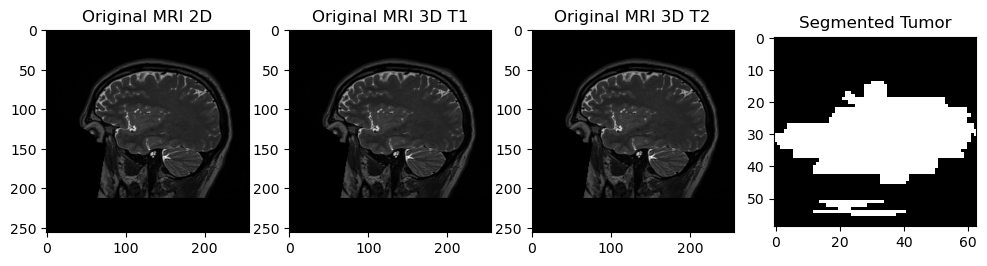

In [617]:
selected_slice_index = 30  # Example index
segmentation_2d = segmentation_image[:, :, selected_slice_index]
print("Selected 2D segmentation shape:", segmentation_2d.shape)

# Data Exploring
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(mri_image3, cmap='gray')
plt.title('Original MRI 2D')

plt.subplot(1, 4, 2)
plt.imshow(mri_image2, cmap='gray')
plt.title('Original MRI 3D T1')

plt.subplot(1, 4, 3)
plt.imshow(mri_image, cmap='gray')
plt.title('Original MRI 3D T2')

plt.subplot(1, 4, 4)
plt.imshow(segmentation_2d, cmap='gray')
plt.title('Segmented Tumor')

plt.show()


In [618]:
def dicom2nifti(image_dir, out_dir, save=True):
    reader = sitk.ImageSeriesReader()
    reader.LoadPrivateTagsOn()
    filenamesDICOM = reader.GetGDCMSeriesFileNames(str(image_dir))
    reader.SetFileNames(filenamesDICOM)
    img = reader.Execute()
    img = sitk.Cast(img, sitk.sitkFloat32)
    
    if save:
        filename = os.path.basename(image_dir)  # Gets the last part of the path
        out_file_path = os.path.join(out_dir, filename + '.nii')
        sitk.WriteImage(img, out_file_path)
    else:
        return img

In [619]:
output_folder = 'data/data_orig/img_nii/ReMIND-001'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [620]:
dicom_mri = 'data/data_orig/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/3.000000-3DSAGT2SPACE-84847'
dicom2nifti(dicom_mri, output_folder)

ImageSeriesReader (0x1428a47e0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000949484



(192, 256, 256)


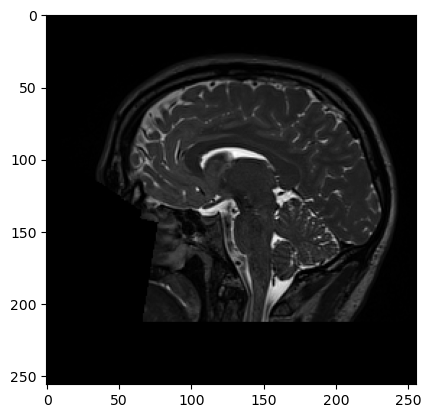

In [621]:
mri_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-001/3.000000-3DSAGT2SPACE-84847.nii', sitk.sitkFloat32)
imgd = sitk.GetArrayFromImage(mri_image)
print(imgd.shape)
plt.imshow(imgd[100], cmap='gray')

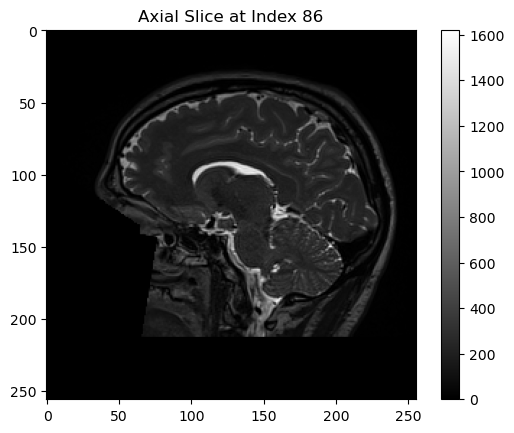

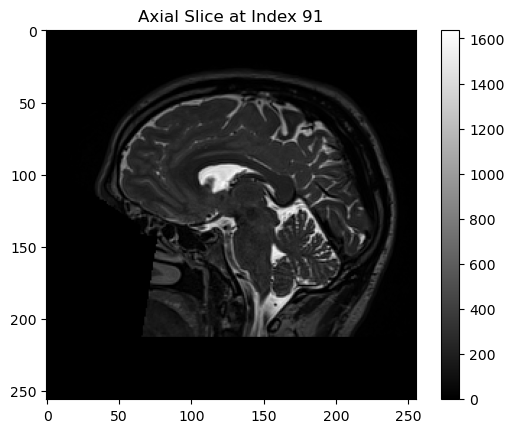

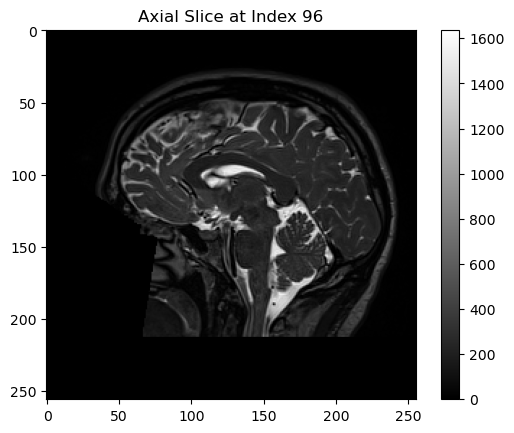

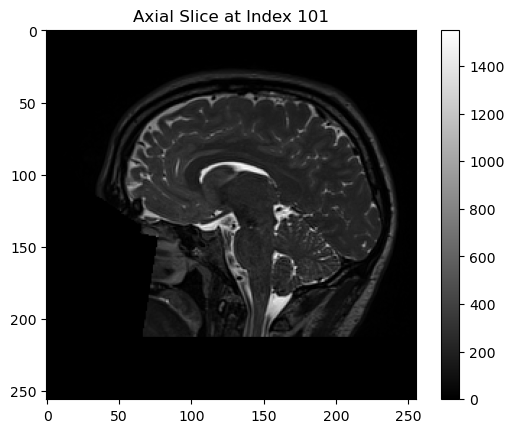

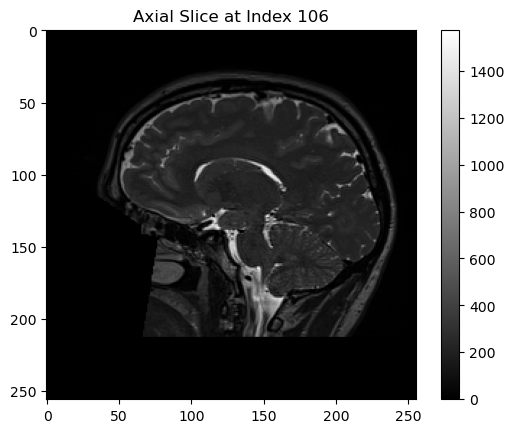

In [622]:
axial_slice_num = imgd.shape[0] // 2

for offset in range(-10, 11, 5):  # This will show slices -10, -5, 0, 5, and 10 from the middle slice
    slice_to_view = axial_slice_num + offset
    plt.imshow(imgd[slice_to_view, :, :], cmap='gray')
    plt.colorbar()
    plt.title(f"Axial Slice at Index {slice_to_view}")
    plt.show()


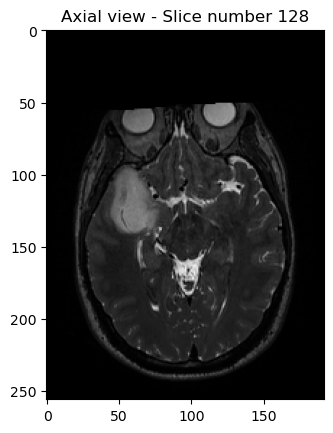

In [623]:
# Load the NIfTI file
nii_img = nib.load('data/data_orig/img_nii/ReMIND-001/3.000000-3DSAGT2SPACE-84847.nii')

# Get the data array
data = nii_img.get_fdata()

# Get the affine matrix that brings the image to RAS+ orientation
canonical_img = nib.as_closest_canonical(nii_img)

# Extract the data array from the reoriented image
canonical_data = canonical_img.get_fdata()

# Find the middle slice index in the first dimension (axial)
middle_slice_index = canonical_data.shape[2] // 2

# Now visualize the middle axial slice
plt.imshow(np.fliplr(np.rot90(canonical_data[:, :, middle_slice_index])), cmap='gray')
plt.title(f'Axial view - Slice number {middle_slice_index}')
plt.show()


In [624]:
def dicom2nifti_segmentation(image_dir, out_dir, save=True):
    reader = sitk.ImageSeriesReader()
    reader.LoadPrivateTagsOn()
    filenamesDICOM = reader.GetGDCMSeriesFileNames(str(image_dir))
    reader.SetFileNames(filenamesDICOM)
    img = reader.Execute()  # Load the image
    
    if save:
        filename = os.path.basename(image_dir)  # Gets the last part of the path
        out_file_path = os.path.join(out_dir, filename + '.nii')
        sitk.WriteImage(img, out_file_path)  # Write without changing type
    else:
        return img


In [625]:
dicom_segmentation = 'data/data_orig/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/303.000000-tumor seg - MR ref 3DSAGT2SPACE-20521'
dicom2nifti_segmentation(dicom_segmentation, output_folder)

(59, 63, 61)


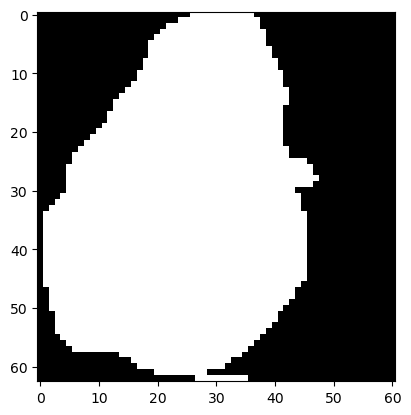

In [626]:
ref_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-001/303.000000-tumor seg - MR ref 3DSAGT2SPACE-20521.nii', sitk.sitkFloat32)
imgd = sitk.GetArrayFromImage(ref_image)
print(imgd.shape)
plt.imshow(imgd[30], cmap='gray')

In [627]:
mri_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-001/3.000000-3DSAGT2SPACE-84847.nii')
segmentation_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-001/303.000000-tumor seg - MR ref 3DSAGT2SPACE-20521.nii')

In [628]:
mri_img_nib = nib.load('data/data_orig/img_nii/ReMIND-001/3.000000-3DSAGT2SPACE-84847.nii')
seg_img_nib = nib.load('data/data_orig/img_nii/ReMIND-001/303.000000-tumor seg - MR ref 3DSAGT2SPACE-20521.nii')

In [629]:
mri_image_nib = mri_img_nib.get_fdata()

seg_image_nib = seg_img_nib.get_fdata()

print("MRI-Bild Abmessungen:", mri_image_nib.shape)
print("Segmentierungsabmessungen:", seg_image_nib.shape)

MRI-Bild Abmessungen: (256, 256, 192)
Segmentierungsabmessungen: (61, 63, 59, 1)


In [630]:
def resampling(mri_image, segmentation_image, path_to_save):
    mri_spacing = mri_image.GetSpacing()
    mri_origin = mri_image.GetOrigin()
    mri_direction = mri_image.GetDirection()

    # Resample the segmentation to match the MRI's space
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(mri_image)  # Use the MRI as a reference
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)  # Nearest neighbor interpolation for label images

    # Apply the transformation
    resampled_segmentation = resampler.Execute(segmentation_image)

    # Save or return the resampled image
    sitk.WriteImage(resampled_segmentation, path_to_save)
    
    return path_to_save

In [631]:
# Function to load and orient NIfTI images to RAS+
def load_nifti_in_RAS(nii_img):
    canonical_img = nib.as_closest_canonical(nii_img)
    return canonical_img.get_fdata()

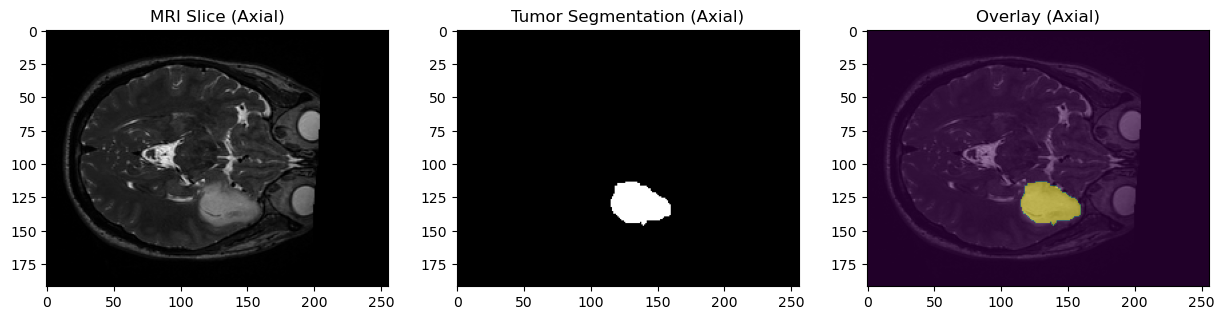

In [632]:
resampled_segmentation_nib = nib.load(resampling(mri_image, segmentation_image, 'data/data_orig/img_nii/ReMIND-001/resampled_segmented_tumor.nii'))

# Load and orient both the MRI and the segmentation
mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(resampled_segmentation_nib)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = mri_data.shape[2] // 2  # adjust as necessary

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['MRI Slice (Axial)', 'Tumor Segmentation (Axial)', 'Overlay (Axial)']

# Plot MRI Slice (Axial)
axes[0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1].set_title(titles[1])

# Plot Overlay (Axial)
axes[2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[2].set_title(titles[2])

# Display the plots
plt.show()


In [633]:
for patiend_id in range(1,6):
    output_folder = f'data/data_orig/img_nii/ReMIND-00{patiend_id}'
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)


In [634]:
dicom2nifti('data/data_orig/ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/2.000000-3DAXT2SPACE-39478', 'data/data_orig/img_nii/ReMIND-002')
dicom2nifti_segmentation('data/data_orig/ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/303.000000-tumor seg - MR ref 3DAXT2SPACE-74106', 'data/data_orig/img_nii/ReMIND-002')

dicom2nifti('data/data_orig/ReMIND/ReMIND-003/12-25-1982-NA-Preop-14674/4.000000-3DAXT2SPACE-70358', 'data/data_orig/img_nii/ReMIND-003')
dicom2nifti_segmentation('data/data_orig/ReMIND/ReMIND-003/12-25-1982-NA-Preop-14674/303.000000-tumor seg - MR ref 3DAXT2SPACE-08306', 'data/data_orig/img_nii/ReMIND-003')



ImageSeriesReader (0x338220ac0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000864562

ImageSeriesReader (0x338220ac0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00051005



In [635]:
mri_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-002/2.000000-3DAXT2SPACE-39478.nii')
segmentation_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-002/303.000000-tumor seg - MR ref 3DAXT2SPACE-74106.nii')

mri_img_nib = nib.load('data/data_orig/img_nii/ReMIND-002/2.000000-3DAXT2SPACE-39478.nii')
seg_img_nib = nib.load('data/data_orig/img_nii/ReMIND-002/303.000000-tumor seg - MR ref 3DAXT2SPACE-74106.nii')

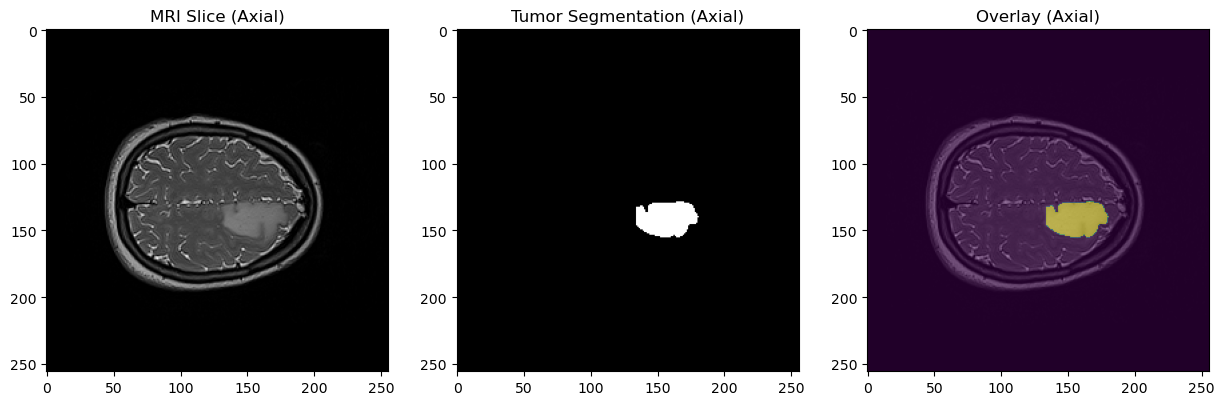

In [636]:
resampled_segmentation_nib = nib.load(resampling(mri_image, segmentation_image, 'data/data_orig/img_nii/ReMIND-002/resampled_segmented_tumor.nii'))

# Load and orient both the MRI and the segmentation
mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(resampled_segmentation_nib)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = 150  # adjust as necessary

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['MRI Slice (Axial)', 'Tumor Segmentation (Axial)', 'Overlay (Axial)']

# Plot MRI Slice (Axial)
axes[0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1].set_title(titles[1])

# Plot Overlay (Axial)
axes[2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[2].set_title(titles[2])

# Display the plots
plt.show()


In [637]:
mri_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-003/4.000000-3DAXT2SPACE-70358.nii')
segmentation_image = sitk.ReadImage('data/data_orig/img_nii/ReMIND-003/303.000000-tumor seg - MR ref 3DAXT2SPACE-08306.nii')

mri_img_nib = nib.load('data/data_orig/img_nii/ReMIND-003/4.000000-3DAXT2SPACE-70358.nii')
seg_img_nib = nib.load('data/data_orig/img_nii/ReMIND-003/303.000000-tumor seg - MR ref 3DAXT2SPACE-08306.nii')

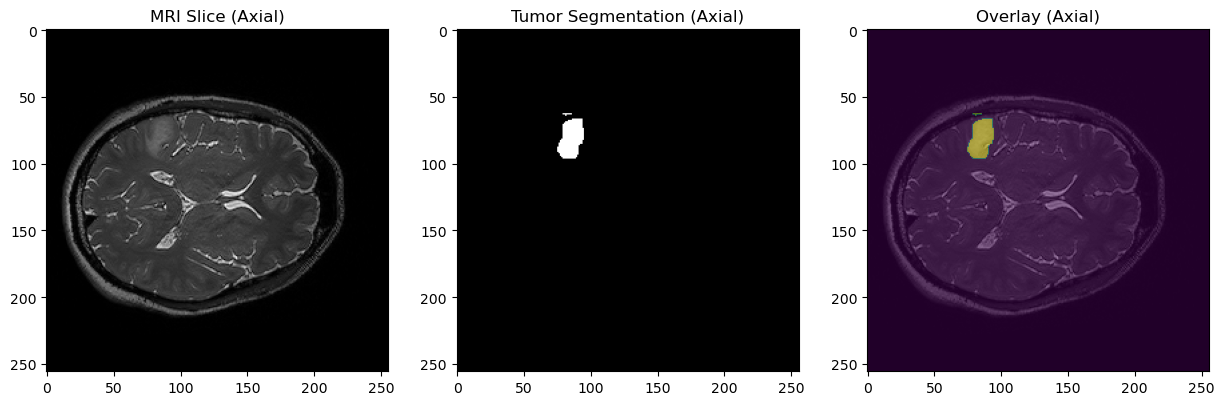

In [638]:
resampled_segmentation_nib = nib.load(resampling(mri_image, segmentation_image, 'data/data_orig/img_nii/ReMIND-003/resampled_segmented_tumor.nii'))

# Load and orient both the MRI and the segmentation
mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(resampled_segmentation_nib)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = 110 # adjust as necessary

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['MRI Slice (Axial)', 'Tumor Segmentation (Axial)', 'Overlay (Axial)']

# Plot MRI Slice (Axial)
axes[0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1].set_title(titles[1])

# Plot Overlay (Axial)
axes[2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[2].set_title(titles[2])

# Display the plots
plt.show()


## Preprocessing for Model

In [639]:
nnunet_raw_path = 'data/nnunet/nnunet_raw'
nnunet_preprocessed_path = 'data/nnunet/nnunet_preprocessed'
nnunet_results_path = 'data/nnunet/nnunet_results'

dataset_dir = os.path.join(nnunet_raw_path, 'Dataset001-REMIND')
imagesTr = os.path.join(dataset_dir, 'imagesTr')
labelsTr = os.path.join(dataset_dir, 'labelsTr')
imagesTs = os.path.join(dataset_dir, 'imagesTs')


folders = [nnunet_raw_path, nnunet_preprocessed_path, nnunet_results_path, dataset_dir, imagesTr, labelsTr, imagesTs]

for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)

In [640]:
metadata2 = metadata[(metadata['Study Description'] == 'Preop')]

#print count patients, and number of rows
print("Number of patients:", len(metadata2['Subject ID'].unique()))
print("Number of rows:", len(metadata2))


# remove all Modality = SEG expcept for the tumor segmentation (Series Descirption should contain tumor) but keep all the other modalities (T1, T2, T1c
metadata2 = metadata2[(metadata2['Modality'] != 'SEG') | (metadata2['Series Description'].str.contains('tumor'))]

print("Number of patients:", len(metadata2['Subject ID'].unique()))
print("Number of rows:", len(metadata2))

# check if there is no tumor segmentation for üatients, remove the whole patient (Subject ID) and all its modalities
removed_patient= metadata2[~metadata2['Subject ID'].isin(metadata2[metadata2['Modality'] == 'SEG']['Subject ID'])]
metadata2 = metadata2[metadata2['Subject ID'].isin(metadata2[metadata2['Modality'] == 'SEG']['Subject ID'])]

print("Number of patients:", len(metadata2['Subject ID'].unique()))
print("Number of rows:", len(metadata2))
print("Removed patients:", removed_patient['Subject ID'].unique())

metadata2

#remove all columns beside the following columns (Subject ID, Modality, Series Description, File Location)
metadata2 = metadata2[['Subject ID', 'Modality', 'Series Description', 'File Location']]
metadata2

# check if there is one than more tumor segmentation for üatients
modalities1 = metadata2[metadata2['Series Description'].str.contains('tumor')].groupby('Subject ID').count()

# filter on modalities1 to get only the patients with more than one tumor segmentation
modalities2 = modalities1[modalities1['Modality'] > 1]
modalities2



Number of patients: 114
Number of rows: 663
Number of patients: 114
Number of rows: 499
Number of patients: 113
Number of rows: 495
Removed patients: ['ReMIND-032']


,Modality,Series Description,File Location
Subject ID,,,
ReMIND-002,2,2,2
ReMIND-004,2,2,2
ReMIND-012,2,2,2
ReMIND-045,2,2,2
ReMIND-055,2,2,2
ReMIND-060,2,2,2
ReMIND-066,2,2,2
ReMIND-067,2,2,2
ReMIND-074,2,2,2


In [641]:
# Step 1: Filter for 'Preop' and segmentation files
metadata_preop = metadata[(metadata['Study Description'] == 'Preop')]
metadata_preop = metadata_preop[(metadata_preop['Modality'] != 'SEG') | (metadata_preop['Series Description'].str.contains('tumor'))]
metadata_preop = metadata_preop[metadata_preop['Subject ID'].isin(metadata_preop[metadata_preop['Modality'] == 'SEG']['Subject ID'])]
metadata_preop = metadata_preop[['Subject ID', 'Modality', 'Series Description', 'File Location']]

print("Number of patients:", len(metadata_preop['Subject ID'].unique()))
print("Number of rows:", len(metadata_preop))
seg_files = metadata_preop[metadata_preop['Modality'] == 'SEG']
seg_files = seg_files[seg_files['Series Description'].str.contains('tumor seg')]

# Step 2: Identify duplicates (more than one segmentation per subject)
dup_subjects = seg_files['Subject ID'][seg_files['Subject ID'].duplicated(keep=False)]
print("Number of subjects with multiple segmentations:", len(dup_subjects.unique()))
print("Number of segfile:", len(seg_files))

# Step 3: For subjects with multiple segmentations, preferentially keep T2
for subject in dup_subjects.unique():
    subject_segs = seg_files[seg_files['Subject ID'] == subject]
    #print(subject_segs)

    # Check if T2 exists for the subject
    D_seg = subject_segs[subject_segs['Series Description'].str.contains('3D')]
    T2_seg = D_seg[D_seg['Series Description'].str.contains('T2')]
    if not T2_seg.empty:
        # Keep only T2 segmentation
        seg_files = seg_files.drop(subject_segs.index)
        #print("drop segmentation:", subject_segs)
        #check if T2_seg has more than one row
        if len(T2_seg) > 1:
            #keep only the first row
            # if T2_seg series description is SPace, keep it else iloc[0]
            if T2_seg['Series Description'].str.contains('SPACE').any():
                T2_seg = T2_seg[T2_seg['Series Description'].str.contains('SPACE')]
            else:
                T2_seg = T2_seg.iloc[[0]]
        seg_files = pd.concat([seg_files, T2_seg])
        #print("concat segmentation:", T2_seg)
    else:
        # No T2 segmentation available, you might keep the first or apply other criteria
        seg_files = seg_files.drop(subject_segs.index[1:])

#number of metadata_preop and seg_files
print("Number of patients:", len(metadata_preop['Subject ID'].unique()))
print("Number of rows:", len(metadata_preop))
print(len(metadata_preop[metadata_preop['Modality'] == 'SEG']))
print(len(metadata_preop[metadata_preop['Modality'] != 'SEG']))
print("Number of segfile_clean:", len(seg_files['Subject ID'].unique()))
print("Number of rows:", len(seg_files))

# Step 4: Merge back the filtered segmentation files with the other modalities
metadata_cleaned = pd.concat([metadata_preop[metadata_preop['Modality'] != 'SEG'], seg_files])

# Keeping only necessary columns
metadata_cleaned = metadata_cleaned[['Subject ID', 'Modality', 'Series Description', 'File Location']]

print("Number of patients:", len(metadata_cleaned['Subject ID'].unique()))
print("Number of rows:", len(metadata_cleaned))

# Display the first few rows to verify
metadata_cleaned.head()


Number of patients: 113
Number of rows: 495
Number of subjects with multiple segmentations: 14
Number of segfile: 127
Number of patients: 113
Number of rows: 495
130
365
Number of segfile_clean: 113
Number of rows: 113
Number of patients: 113
Number of rows: 478


,Subject ID,Modality,Series Description,File Location
8,ReMIND-001,MR,3DSAGT2SPACE,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/3.000000-3DSAGT2SPACE-84847
9,ReMIND-001,MR,3DAXT1postcontrast,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/2.000000-3DAXT1postcontrast-94802
11,ReMIND-001,MR,2DCORT2BLADE,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/1.000000-2DCORT2BLADE-23942
19,ReMIND-002,MR,3DAXT2SPACE,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/2.000000-3DAXT2SPACE-39478
20,ReMIND-002,MR,3DAXT1postcontrast,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/1.000000-3DAXT1postcontrast-17667


Check if there is a T1 and T2 image for every patient

In [642]:
import pandas as pd

# Define the mapping function
def map_series_to_label(series_description):
    # Convert to lower case for consistent comparison
    series_description = series_description.lower()
    if "t1" in series_description:
        return 'T1'
    elif "t2" in series_description:
        return 'T2'
    else:
        return 'Other'

# Assuming metadata_cleaned is your DataFrame and it's correctly loaded
# Apply the mapping function to your metadata
metadata_cleaned['Mapped_Label_v2'] = metadata_cleaned['Series Description'].apply(map_series_to_label)

# Group data by Subject ID and check for the presence of at least one T1 and one T2
# Create a summary DataFrame to hold this info
patient_summary = metadata_cleaned.groupby('Subject ID')['Mapped_Label_v2'].agg(list)

# Define a function to check each patient's mapped labels
def check_t1_t2_presence(labels_list):
    return 'T1' in labels_list and 'T2' in labels_list

# Apply the function to each patient's series list
patient_summary = patient_summary.apply(check_t1_t2_presence)

# Now patient_summary is a Series with Subject ID as index and True/False as values indicating the presence of both T1 and T2
print(patient_summary)

# Optional: Filter original metadata for patients with both T1 and T2
patients_with_both = patient_summary[patient_summary].index.tolist()
filtered_metadata = metadata_cleaned[metadata2['Subject ID'].isin(patients_with_both)]

# display filtered_metadata where it is False
filtered_metadata[~filtered_metadata['Subject ID'].isin(patients_with_both)]


Subject ID
ReMIND-001    True
ReMIND-002    True
ReMIND-003    True
ReMIND-004    True
ReMIND-005    True
              ... 
ReMIND-110    True
ReMIND-111    True
ReMIND-112    True
ReMIND-113    True
ReMIND-114    True
Name: Mapped_Label_v2, Length: 113, dtype: bool


/var/folders/bf/3n7wxjyn0rl9rrhzmyw8mb7w0000gn/T/ipykernel_60960/422395480.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metadata = metadata_cleaned[metadata2['Subject ID'].isin(patients_with_both)]


,Subject ID,Modality,Series Description,File Location,Mapped_Label_v2


In [643]:
# Import necessary libraries
import pandas as pd

# Function to extract MRI reference from tumor segmentation descriptions
def extract_mri_reference(series_description):
    if "tumor seg - MR ref" in series_description:
        # Assuming the format is consistent as 'tumor seg - MR ref MRI_REFERENCE'
        return series_description.split('MR ref ')[1].strip()  # Extracts and returns the MRI reference
    return None  # Returns None if not a tumor segmentation entry

# Apply the function to the 'Series Description' column
metadata_cleaned['MRI_Ref'] = metadata_cleaned['Series Description'].apply(extract_mri_reference)


In [644]:
# Iterate through metadata, flagging MRIs that match the reference
for index, row in metadata_cleaned.iterrows():
    # Check if it's a tumor segmentation with a valid MRI reference
    if row['MRI_Ref']:
        # Find and flag the corresponding MRI entry
        for i, r in metadata_cleaned.iterrows():
            # Ensure same patient and the MRI reference matches the Series Description
            if r['Subject ID'] == row['Subject ID'] and row['MRI_Ref'] in r['Series Description']:
                metadata_cleaned.at[i, 'Flagged_for_Segmentation'] = True  # Flag the entry

# Fill NaNs for unflagged entries in the new column
metadata_cleaned['Flagged_for_Segmentation'] = metadata_cleaned['Flagged_for_Segmentation'].fillna(False)


/var/folders/bf/3n7wxjyn0rl9rrhzmyw8mb7w0000gn/T/ipykernel_60960/3884393428.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metadata_cleaned.at[i, 'Flagged_for_Segmentation'] = True  # Flag the entry


In [645]:
metadata_cleaned[metadata_cleaned['Subject ID'] == 'ReMIND-007']

,Subject ID,Modality,Series Description,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation
71,ReMIND-007,MR,3DAXT1postcontrast,./ReMIND/ReMIND-007/12-25-1982-NA-Preop-57336/2.000000-3DAXT1postcontrast-48074,T1,None,True
72,ReMIND-007,MR,2DAXT2,./ReMIND/ReMIND-007/12-25-1982-NA-Preop-57336/1.000000-2DAXT2-39696,T2,None,False
68,ReMIND-007,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-007/12-25-1982-NA-Preop-57336/303.000000-tumor seg - MR ref 3DAXT1postcontrast-54943,T1,3DAXT1postcontrast,True


In [646]:
#distinct on series description and filter on modality MR
metadata_cleaned[metadata_cleaned['Modality'] == 'MR'].groupby('Series Description').count()

,Subject ID,Modality,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation
Series Description,,,,,,
2DAXT2,36,36,36,36,0,36
2DAXT2BLADE,26,26,26,26,0,26
2DAXT2FLAIR,63,63,63,63,0,63
2DCORT2BLADE,21,21,21,21,0,21
2DCORT2FLAIR,4,4,4,4,0,4
2DSAGT2BLADE,2,2,2,2,0,2
2DSAGT2FLAIR,3,3,3,3,0,3
3DAXT1MP2RAGE,3,3,3,3,0,3
3DAXT1postcontrast,103,103,103,103,0,103


In [647]:
def map_series_to_label(series_description):
    series_description = series_description.lower()  # Convert to lower case
    
    # Exclude conditions like 'tumor seg'
    if 'tumor seg' in series_description:
        return ''  # or return 'Exclude' or similar to indicate it should be excluded
    
    if "t1" in series_description and "postcontrast" in series_description:
        return 'T1ce'
    elif "t1" in series_description:
        return 'T1'
    elif "t2" in series_description and "flair" in series_description:
        return 'FLAIR'
    elif "t2" in series_description and "space" in series_description:
        return 'T2_SPACE'
    elif "t2" in series_description:
        return 'T2'
    else:
        return 'Other'  # Catch-all for any other series descriptions


# Apply the mapping function to your metadata
metadata_cleaned['Mapped_Label'] = metadata_cleaned['Series Description'].apply(map_series_to_label)

# Display the distinct mappings
distinct_mappings = metadata_cleaned[['Series Description', 'Mapped_Label']].drop_duplicates()
distinct_mappings

,Series Description,Mapped_Label
8,3DSAGT2SPACE,T2_SPACE
9,3DAXT1postcontrast,T1ce
11,2DCORT2BLADE,T2
19,3DAXT2SPACE,T2_SPACE
28,2DAXT2BLADE,T2
54,3DSAGT2FLAIR,FLAIR
55,3DAXT1precontrast,T1
72,2DAXT2,T2
89,2DAXT2FLAIR,FLAIR
109,2DCORT2FLAIR,FLAIR


In [648]:
import pandas as pd

# Assuming metadata_cleaned is already defined and Mapped_Label is already applied

# Group by Subject ID and Mapped_Label and count the occurrences
category_counts_per_patient = metadata_cleaned.groupby(['Subject ID', 'Mapped_Label']).size()

# Convert the series to a DataFrame for easier handling
category_counts_df = category_counts_per_patient.reset_index(name='Counts')

# Filter for patients with more than two files in any one category
patients_with_issues = category_counts_df[category_counts_df['Counts'] > 1]

# Print or further analyze patients with issues
print(patients_with_issues)


     Subject ID Mapped_Label  Counts
9    ReMIND-003           T2       2
29   ReMIND-009           T2       2
31   ReMIND-010        FLAIR       2
36   ReMIND-011           T2       2
79   ReMIND-021           T2       2
88   ReMIND-023           T2       2
91   ReMIND-024           T2       2
108  ReMIND-029           T2       2
180  ReMIND-049        FLAIR       2
191  ReMIND-051           T2       2
196  ReMIND-052           T2       2
200  ReMIND-053           T2       2
207  ReMIND-055        FLAIR       2
217  ReMIND-057           T2       2
222  ReMIND-058           T2       2
238  ReMIND-062           T2       2
314  ReMIND-080        FLAIR       2
321  ReMIND-081           T2       2
325  ReMIND-082           T2       2
348  ReMIND-088        FLAIR       3
410  ReMIND-104           T2       2
418  ReMIND-106           T2       2
452  ReMIND-114           T2       2


In [649]:
# Assuming patients_with_issues and metadata_cleaned are defined as before

# Create a list of tuples for filtering (Subject ID, Mapped_Label) from patients_with_issues
issue_filter = list(zip(patients_with_issues['Subject ID'], patients_with_issues['Mapped_Label']))

# Filter metadata_cleaned for these specific issues
detailed_issues = metadata_cleaned[metadata_cleaned.apply(lambda x: (x['Subject ID'], x['Mapped_Label']) in issue_filter, axis=1)]

# Now, detailed_issues contains all the entries from metadata_cleaned that match the problem criteria
detailed_issues


,Subject ID,Modality,Series Description,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation,Mapped_Label
28,ReMIND-003,MR,2DAXT2BLADE,./ReMIND/ReMIND-003/12-25-1982-NA-Preop-14674/1.000000-2DAXT2BLADE-91396,T2,None,False,T2
32,ReMIND-003,MR,2DCORT2BLADE,./ReMIND/ReMIND-003/12-25-1982-NA-Preop-14674/2.000000-2DCORT2BLADE-13240,T2,None,False,T2
94,ReMIND-009,MR,2DCORT2BLADE,./ReMIND/ReMIND-009/12-25-1982-NA-Preop-14466/2.000000-2DCORT2BLADE-51431,T2,None,False,T2
99,ReMIND-009,MR,2DAXT2BLADE,./ReMIND/ReMIND-009/12-25-1982-NA-Preop-14466/1.000000-2DAXT2BLADE-42289,T2,None,True,T2
109,ReMIND-010,MR,2DCORT2FLAIR,./ReMIND/ReMIND-010/12-25-1982-NA-Preop-40071/1.000000-2DCORT2FLAIR-22473,T2,None,False,FLAIR
111,ReMIND-010,MR,3DSAGT2FLAIR,./ReMIND/ReMIND-010/12-25-1982-NA-Preop-40071/3.000000-3DSAGT2FLAIR-07773,T2,None,False,FLAIR
124,ReMIND-011,MR,2DAXT2BLADE,./ReMIND/ReMIND-011/12-25-1982-NA-Preop-66663/1.000000-2DAXT2BLADE-77818,T2,None,True,T2
126,ReMIND-011,MR,2DCORT2BLADE,./ReMIND/ReMIND-011/12-25-1982-NA-Preop-66663/3.000000-2DCORT2BLADE-57721,T2,None,False,T2
245,ReMIND-021,MR,2DAXT2BLADE,./ReMIND/ReMIND-021/12-25-1982-NA-Preop-67639/1.000000-2DAXT2BLADE-53378,T2,None,False,T2
247,ReMIND-021,MR,2DCORT2BLADE,./ReMIND/ReMIND-021/12-25-1982-NA-Preop-67639/3.000000-2DCORT2BLADE-62443,T2,None,False,T2


In [650]:
# Initialize a list to hold indices of entries to remove
indices_to_remove = []
remove = []

# Iterate over each patient in detailed_issues
for patient_id, patient_group in detailed_issues.groupby('Subject ID'):
    # Group further by 'Mapped_Label' (if needed) and process each category
    for _, category_group in patient_group.groupby('Mapped_Label'):
        # Find entries flagged for segmentation
        flagged_entries = category_group[category_group['Flagged_for_Segmentation']]

        # Determine action based on whether there are any flagged entries
        if not flagged_entries.empty:
            # Keep the first flagged entry and mark the rest for removal
            keep_index = flagged_entries.index[0]  # or some logic to pick the best one
            # Add indices of all other entries in this patient's category to removal list
            indices_to_remove.extend(category_group.index.difference([keep_index]))

        else:
            # If no entries are flagged, prioritize AXT file if available
            axt_entries = category_group[category_group['Series Description'].str.contains('AXT')]
            if not axt_entries.empty:
                # If there are AXT files, keep the first one and mark the rest for removal
                keep_index = axt_entries.index[0]
                indices_to_remove.extend(category_group.index.difference([keep_index]))
                remove.append(category_group) 
            else:
                # If no AXT files, then look for SAGT files
                sagt_entries = category_group[category_group['Series Description'].str.contains('SAGT')]
                if not sagt_entries.empty:
                    # If there are SAGT files, keep the first one and mark the rest for removal
                    keep_index = sagt_entries.index[0]
                    indices_to_remove.extend(category_group.index.difference([keep_index]))
                else:
                    # If no AXT or SAGT files, apply other logic or remove all
                    pass  # Adjust as needed, or keep the first, or none

# Now, indices_to_remove contains indices of all non-flagged entries while ensuring at least one entry is
indices_to_remove


[32,
 94,
 109,
 126,
 247,
 267,
 272,
 332,
 561,
 586,
 594,
 612,
 628,
 649,
 663,
 719,
 953,
 964,
 982,
 1043,
 1047,
 1225,
 1249,
 1344]

In [651]:
# Remove the entries from metadata_cleaned
metadata_cleaned = metadata_cleaned.drop(index=indices_to_remove)


In [652]:
# Optional: Re-check the category counts for each patient
category_counts_per_patient = metadata_cleaned.groupby(['Subject ID', 'Mapped_Label']).size()
category_counts_df = category_counts_per_patient.reset_index(name='Counts')

# Identify patients with issues again
patients_with_issues = category_counts_df[category_counts_df['Counts'] > 1]

# Display patients with issues after the removal
print(patients_with_issues)


Empty DataFrame
Columns: [Subject ID, Mapped_Label, Counts]
Index: []


In [653]:
modality_mapping = {
    'T2_SPACE': '0000',
    'FLAIR': '0001',
    'T2': '0002',
    'T1': '0003',
    'T1ce': '0004',
    # Add other modalities and their corresponding identifiers here
    'SEG': '0099'  # assuming SEG is always tumor segmentation for this example
}

# Assign new file names based on modality
metadata_cleaned['new_file_name'] = metadata_cleaned.apply(lambda x: x['Subject ID'].replace('-', '_')   + ('_' + modality_mapping.get(x['Mapped_Label'], '')) if x['Modality'] != 'SEG' else x['Subject ID'].replace('-', '_') , axis=1)

# if the modality is SEG, replace last character in the new file name
#metadata_cleaned['new_file_name'] = metadata_cleaned.apply(lambda x: x['new_file_name'][:-1] + '9' if x['Modality'] == 'SEG' else x['new_file_name'], axis=1)

# Display the first few rows to verify
metadata_cleaned[['Subject ID', 'Modality', 'Series Description', 'Mapped_Label', 'new_file_name']].head()

,Subject ID,Modality,Series Description,Mapped_Label,new_file_name
8,ReMIND-001,MR,3DSAGT2SPACE,T2_SPACE,ReMIND_001_0000
9,ReMIND-001,MR,3DAXT1postcontrast,T1ce,ReMIND_001_0004
11,ReMIND-001,MR,2DCORT2BLADE,T2,ReMIND_001_0002
19,ReMIND-002,MR,3DAXT2SPACE,T2_SPACE,ReMIND_002_0000
20,ReMIND-002,MR,3DAXT1postcontrast,T1ce,ReMIND_002_0004


In [654]:
metadata_cleaned

,Subject ID,Modality,Series Description,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation,Mapped_Label,new_file_name
8,ReMIND-001,MR,3DSAGT2SPACE,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/3.000000-3DSAGT2SPACE-84847,T2,None,True,T2_SPACE,ReMIND_001_0000
9,ReMIND-001,MR,3DAXT1postcontrast,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/2.000000-3DAXT1postcontrast-94802,T1,None,False,T1ce,ReMIND_001_0004
11,ReMIND-001,MR,2DCORT2BLADE,./ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/1.000000-2DCORT2BLADE-23942,T2,None,False,T2,ReMIND_001_0002
19,ReMIND-002,MR,3DAXT2SPACE,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/2.000000-3DAXT2SPACE-39478,T2,None,True,T2_SPACE,ReMIND_002_0000
20,ReMIND-002,MR,3DAXT1postcontrast,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/1.000000-3DAXT1postcontrast-17667,T1,None,False,T1ce,ReMIND_002_0004
...,...,...,...,...,...,...,...,...,...
775,ReMIND-066,SEG,tumor seg - MR ref 3DAXT2SPACE,./ReMIND/ReMIND-066/12-25-1982-NA-Preop-96891/303.000000-tumor seg - MR ref 3DAXT2SPACE-47868,T2,3DAXT2SPACE,True,,ReMIND_066
781,ReMIND-067,SEG,tumor seg - MR ref 3DAXT2SPACE,./ReMIND/ReMIND-067/12-25-1982-NA-Preop-77145/303.000000-tumor seg - MR ref 3DAXT2SPACE-34591,T2,3DAXT2SPACE,True,,ReMIND_067
866,ReMIND-074,SEG,tumor seg - MR ref 3DAXT2SPACE,./ReMIND/ReMIND-074/12-25-1982-NA-Preop-89000/303.000000-tumor seg - MR ref 3DAXT2SPACE-16222,T2,3DAXT2SPACE,True,,ReMIND_074
914,ReMIND-077,SEG,tumor seg - MR ref 3DSAGT2FLAIR,./ReMIND/ReMIND-077/12-25-1982-NA-Preop-68266/303.000000-tumor seg - MR ref 3DSAGT2FLAIR-92931,T2,3DSAGT2FLAIR,True,,ReMIND_077


In [655]:
# Define the root path for your selected data
root_path = 'data/data_selected'

# Adjusting FullFilePath construction
metadata_cleaned['FullFilePath'] = metadata_cleaned['File Location'].apply(lambda x: os.path.join(root_path, x[2:]))

# Now FullFilePath should reflect the actual full path of each file
print(metadata_cleaned['FullFilePath'].head())


8           data/data_selected/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/3.000000-3DSAGT2SPACE-84847
9     data/data_selected/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/2.000000-3DAXT1postcontrast-94802
11          data/data_selected/ReMIND/ReMIND-001/12-25-1982-NA-Preop-56579/1.000000-2DCORT2BLADE-23942
19           data/data_selected/ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/2.000000-3DAXT2SPACE-39478
20    data/data_selected/ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/1.000000-3DAXT1postcontrast-17667
Name: FullFilePath, dtype: object


Filtered again on only the tumor files because the shapes of the different files is not fitting. 



In [656]:
# keep only the flagged in metadata_cleaned
metadata_cleaned = metadata_cleaned[metadata_cleaned['Flagged_for_Segmentation'] == True]

In [657]:
# sum the number of rows for each subject ID and show where it is more than 2
metadata_cleaned.groupby('Subject ID').count().sort_values(by=['Modality'], ascending=False)

,Modality,Series Description,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation,Mapped_Label,new_file_name,FullFilePath
Subject ID,,,,,,,,,
ReMIND-060,3,3,3,3,1,3,3,3,3
ReMIND-101,3,3,3,3,1,3,3,3,3
ReMIND-061,2,2,2,2,1,2,2,2,2
ReMIND-062,2,2,2,2,1,2,2,2,2
ReMIND-084,2,2,2,2,1,2,2,2,2
...,...,...,...,...,...,...,...,...,...
ReMIND-036,2,2,2,2,1,2,2,2,2
ReMIND-035,2,2,2,2,1,2,2,2,2
ReMIND-034,2,2,2,2,1,2,2,2,2


In [658]:
metadata_cleaned[metadata_cleaned['Subject ID'] == 'ReMIND-060']

,Subject ID,Modality,Series Description,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation,Mapped_Label,new_file_name,FullFilePath
696,ReMIND-060,MR,2DAXT2,./ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/1.000000-2DAXT2-40705,T2,None,True,T2,ReMIND_060_0002,data/data_selected/ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/1.000000-2DAXT2-40705
698,ReMIND-060,MR,2DAXT2FLAIR,./ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/2.000000-2DAXT2FLAIR-22012,T2,None,True,FLAIR,ReMIND_060_0001,data/data_selected/ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/2.000000-2DAXT2FLAIR-22012
692,ReMIND-060,SEG,tumor seg - MR ref 2DAXT2,./ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/303.000000-tumor seg - MR ref 2DAXT2-62211,T2,2DAXT2,True,,ReMIND_060,data/data_selected/ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/303.000000-tumor seg - MR ref 2DAXT2-62211


In [659]:
metadata_cleaned[metadata_cleaned['Subject ID'] == 'ReMIND-060']
# get the MRI reference for segmentation
mref = metadata_cleaned[(metadata_cleaned['Subject ID'] == 'ReMIND-060') & (metadata_cleaned['Modality'] == 'SEG')]['MRI_Ref'].values[0]
remove_row = metadata_cleaned[(metadata_cleaned['Subject ID'] == 'ReMIND-060') & (metadata_cleaned['Modality'] == 'MR') & (metadata_cleaned['Series Description'] != mref)]

# remove row from metadata_cleaned
metadata_cleaned = metadata_cleaned.drop(remove_row.index)


In [660]:
metadata_cleaned[metadata_cleaned['Subject ID'] == 'ReMIND-101']

,Subject ID,Modality,Series Description,File Location,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation,Mapped_Label,new_file_name,FullFilePath
1183,ReMIND-101,MR,2DAXT2FLAIR,./ReMIND/ReMIND-101/12-25-1982-NA-Preop-11497/2.000000-2DAXT2FLAIR-38631,T2,None,True,FLAIR,ReMIND_101_0001,data/data_selected/ReMIND/ReMIND-101/12-25-1982-NA-Preop-11497/2.000000-2DAXT2FLAIR-38631
1186,ReMIND-101,MR,2DAXT2,./ReMIND/ReMIND-101/12-25-1982-NA-Preop-11497/1.000000-2DAXT2-80465,T2,None,True,T2,ReMIND_101_0002,data/data_selected/ReMIND/ReMIND-101/12-25-1982-NA-Preop-11497/1.000000-2DAXT2-80465
1180,ReMIND-101,SEG,tumor seg - MR ref 2DAXT2,./ReMIND/ReMIND-101/12-25-1982-NA-Preop-11497/303.000000-tumor seg - MR ref 2DAXT2-89019,T2,2DAXT2,True,,ReMIND_101,data/data_selected/ReMIND/ReMIND-101/12-25-1982-NA-Preop-11497/303.000000-tumor seg - MR ref 2DAXT2-89019


In [661]:
metadata_cleaned[metadata_cleaned['Subject ID'] == 'ReMIND-101']
# get the MRI reference for segmentation
mref = metadata_cleaned[(metadata_cleaned['Subject ID'] == 'ReMIND-101') & (metadata_cleaned['Modality'] == 'SEG')]['MRI_Ref'].values[0]
remove_row = metadata_cleaned[(metadata_cleaned['Subject ID'] == 'ReMIND-101') & (metadata_cleaned['Modality'] == 'MR') & (metadata_cleaned['Series Description'] != mref)]

# remove row from metadata_cleaned
metadata_cleaned = metadata_cleaned.drop(remove_row.index)

In [662]:
import os
import shutil  # for directory operations

# Assuming root_path and metadata_cleaned are already defined
# Ensure target directory exists
target_base_path = "Data/Data_selected/ReMIND_shortened"
os.makedirs(target_base_path, exist_ok=True)

# Normalize paths in kept_dirs_set as before
kept_dirs_set = set(os.path.normpath(path) for path in metadata_cleaned['FullFilePath'].tolist())

# Iterate and copy directories
for kept_dir in kept_dirs_set:
    # Calculate the relative path of the directory with respect to root_path
    relative_path = os.path.relpath(kept_dir, root_path)
    
    # Define the new directory path including the relative path to preserve folder structure
    new_dir_path = os.path.join(target_base_path, relative_path)
    
    # Ensure the target subdirectory exists or create it
    os.makedirs(os.path.dirname(new_dir_path), exist_ok=True)
    
    # Check if the directory exists and then copy
    if os.path.isdir(kept_dir):
        try:
            shutil.copytree(kept_dir, new_dir_path)
            print(f"Copied {kept_dir} to {new_dir_path}")
        except Exception as e:
            print(f"Failed to copy {kept_dir}. Reason: {e}")
    else:
        print(f"Directory does not exist and cannot be copied: {kept_dir}")

print(f"Copied {len(kept_dirs_set)} directories to {target_base_path}.")


Failed to copy data/data_selected/ReMIND/ReMIND-056/12-25-1982-NA-Preop-54999/303.000000-tumor seg - MR ref 3DAXT2SPACE-70150. Reason: [Errno 17] File exists: 'Data/Data_selected/ReMIND_shortened/ReMIND/ReMIND-056/12-25-1982-NA-Preop-54999/303.000000-tumor seg - MR ref 3DAXT2SPACE-70150'
Failed to copy data/data_selected/ReMIND/ReMIND-041/12-25-1982-NA-Preop-57083/303.000000-tumor seg - MR ref 3DAXT2SPACE-81845. Reason: [Errno 17] File exists: 'Data/Data_selected/ReMIND_shortened/ReMIND/ReMIND-041/12-25-1982-NA-Preop-57083/303.000000-tumor seg - MR ref 3DAXT2SPACE-81845'
Failed to copy data/data_selected/ReMIND/ReMIND-053/12-25-1982-NA-Preop-36118/1.000000-2DAXT2BLADE-60135. Reason: [Errno 17] File exists: 'Data/Data_selected/ReMIND_shortened/ReMIND/ReMIND-053/12-25-1982-NA-Preop-36118/1.000000-2DAXT2BLADE-60135'
Failed to copy data/data_selected/ReMIND/ReMIND-111/12-25-1982-NA-Preop-58058/2.000000-2DAXT2FLAIR-02382. Reason: [Errno 17] File exists: 'Data/Data_selected/ReMIND_shortened/

In [663]:
# Process and save MRI files
for index, row in metadata_cleaned.iterrows():
    # Check if the row corresponds to an MRI file
    if row['Modality'] != 'SEG':
        image_dir = row['FullFilePath']
        original_file_name = row['new_file_name'] + '.nii'
        new_file_name = row['new_file_name'] + '.nii.gz'

        # Convert MRI to NIfTI and save
        nifti_img = dicom2nifti(image_dir, imagesTr, save=False)

        # Write the converted MRI image
        original_nii_path = os.path.join(imagesTr, original_file_name)
        sitk.WriteImage(nifti_img, original_nii_path)
        print(f"Saved original MRI: {original_file_name}")



ImageSeriesReader (0x33aa09af0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000949484



Saved original MRI: ReMIND_001_0000.nii


ImageSeriesReader (0x338220ac0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000864562



Saved original MRI: ReMIND_002_0000.nii


ImageSeriesReader (0x338220ac0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00051005



...

ImageSeriesReader (0x2a29fc3a0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00126677



Saved original MRI: ReMIND_110_0004.nii
Saved original MRI: ReMIND_111_0001.nii


ImageSeriesReader (0x2a29fc3a0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000741737

ImageSeriesReader (0x1340df8b0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000914001



Saved original MRI: ReMIND_112_0004.nii
Saved original MRI: ReMIND_113_0004.nii
Saved original MRI: ReMIND_114_0000.nii


ImageSeriesReader (0x2a29fc3a0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000701945



In [664]:
# Process and save MRI files
for index, row in metadata_cleaned.iterrows():
    # Check if the row corresponds to an MRI file
    if row['Modality'] == 'SEG':
        image_dir = row['FullFilePath']
        original_file_name = row['new_file_name'] + '.nii'
        new_file_name = row['new_file_name'] + '.nii.gz'

        # Convert MRI to NIfTI and save
        nifti_img = dicom2nifti_segmentation(image_dir, labelsTr, save=False)
        sitk.WriteImage(nifti_img, os.path.join(labelsTr, original_file_name))

In [665]:
def load_corresponding_mri(segmentation_row, metadata_df):
    patient_id = segmentation_row['Subject ID']
    # Additional criteria to match the segmentation to its MRI
    # For example, you might match based on some attributes of 'Series Description' or other metadata
    
    # Find the corresponding MRI in the metadata_df
    # This is a placeholder for your logic to find the matching MRI entry
    mri_entry = metadata_df[(metadata_df['Subject ID'] == patient_id) & (metadata_df['Flagged_for_Segmentation'] == True) & (metadata_df['Modality'] == 'MR')]  # Add additional matching criteria

    if not mri_entry.empty:
        # Assuming the first entry is the correct one
        mri_path = os.path.join(imagesTr, mri_entry.iloc[0]['new_file_name'] + '.nii')
        print(f"Found MRI for {patient_id}: {mri_path}")
        mri_image = sitk.ReadImage(mri_path)
        return mri_image
    else:
        return None  # or handle the missing MRI case as appropriate


In [666]:
def resampling(mri_image, segmentation_image, path_to_save):
    mri_spacing = mri_image.GetSpacing()
    mri_origin = mri_image.GetOrigin()
    mri_direction = mri_image.GetDirection()

    # Resample the segmentation to match the MRI's space
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(mri_image)  # Use the MRI as a reference
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)  # Nearest neighbor interpolation for label images

    # Apply the transformation
    resampled_segmentation = resampler.Execute(segmentation_image)

    # Save or return the resampled image
    #sitk.WriteImage(resampled_segmentation, path_to_save)
    
    return resampled_segmentation

In [667]:
# Process and save segmentation files
for index, row in metadata_cleaned.iterrows():
    # Check if the row corresponds to a segmentation file
    if row['Modality'] == 'SEG':
        image_dir = labelsTr
        original_file_name = row['new_file_name'] + '.nii'
        new_file_name = row['new_file_name'] + '.nii'

        # Load the corresponding MRI
        mri_image = load_corresponding_mri(row, metadata_cleaned)  # Implement this function based on your data
        segmentation_image = sitk.ReadImage(os.path.join(image_dir, original_file_name))
        if mri_image:  # Proceed if a corresponding MRI was found
            # Convert segmentation to NIfTI
            resampling_img = resampling(mri_image, segmentation_image, os.path.join(labelsTr, new_file_name))
            sitk.WriteImage(resampling_img, os.path.join(labelsTr, original_file_name))
        else:
            print(f"No corresponding MRI found for segmentation: {original_file_name}")
        

Found MRI for ReMIND-001: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_001_0000.nii
Found MRI for ReMIND-003: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_003_0000.nii
Found MRI for ReMIND-005: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_005_0000.nii
Found MRI for ReMIND-006: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_006_0000.nii
Found MRI for ReMIND-007: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_007_0004.nii
Found MRI for ReMIND-008: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_008_0004.nii
Found MRI for ReMIND-009: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_009_0002.nii
Found MRI for ReMIND-010: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_010_0004.nii
Found MRI for ReMIND-011: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_011_0002.nii
Found MRI for ReMIND-013: data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_013_0004.nii
Found MRI for ReMIND-014: data/nnunet/nn

In [668]:
# Process and save MRI files
for index, row in metadata_cleaned.iterrows():
    # Check if the row corresponds to an MRI file

    original_file_name = row['new_file_name'] + '.nii'
    new_file_name = row['new_file_name'] + '.nii.gz'
    
    # if modality = 'SEG' then path = 'labelsTr' else path = 'imagesTr'
    if row['Modality'] == 'SEG':
        image_dir = labelsTr
    else:
        image_dir = imagesTr

    nifti_img = nib.load(os.path.join(image_dir, original_file_name))
    # Convert MRI to NIfTI and save
    nifti_data = load_nifti_in_RAS(nifti_img)

    new_nii_img = nib.Nifti1Image(nifti_data, affine=np.eye(4))
    nib.save(new_nii_img, os.path.join(image_dir, new_file_name))

    print(f"Saved reoriented MRI as: {new_file_name}")

    # Remove the original .nii file
    os.remove(os.path.join(image_dir, original_file_name))
    print(f"Removed original MRI: {original_file_name}")


Saved reoriented MRI as: ReMIND_001_0000.nii.gz
Removed original MRI: ReMIND_001_0000.nii
Saved reoriented MRI as: ReMIND_002_0000.nii.gz
Removed original MRI: ReMIND_002_0000.nii
Saved reoriented MRI as: ReMIND_003_0000.nii.gz
Removed original MRI: ReMIND_003_0000.nii
Saved reoriented MRI as: ReMIND_004_0000.nii.gz
Removed original MRI: ReMIND_004_0000.nii
Saved reoriented MRI as: ReMIND_005_0000.nii.gz
Removed original MRI: ReMIND_005_0000.nii
Saved reoriented MRI as: ReMIND_006_0000.nii.gz
Removed original MRI: ReMIND_006_0000.nii
Saved reoriented MRI as: ReMIND_007_0004.nii.gz
Removed original MRI: ReMIND_007_0004.nii
Saved reoriented MRI as: ReMIND_009_0002.nii.gz
Removed original MRI: ReMIND_009_0002.nii
Saved reoriented MRI as: ReMIND_008_0004.nii.gz
Removed original MRI: ReMIND_008_0004.nii
Saved reoriented MRI as: ReMIND_010_0004.nii.gz
Removed original MRI: ReMIND_010_0004.nii
Saved reoriented MRI as: ReMIND_011_0002.nii.gz
Removed original MRI: ReMIND_011_0002.nii
Saved reor

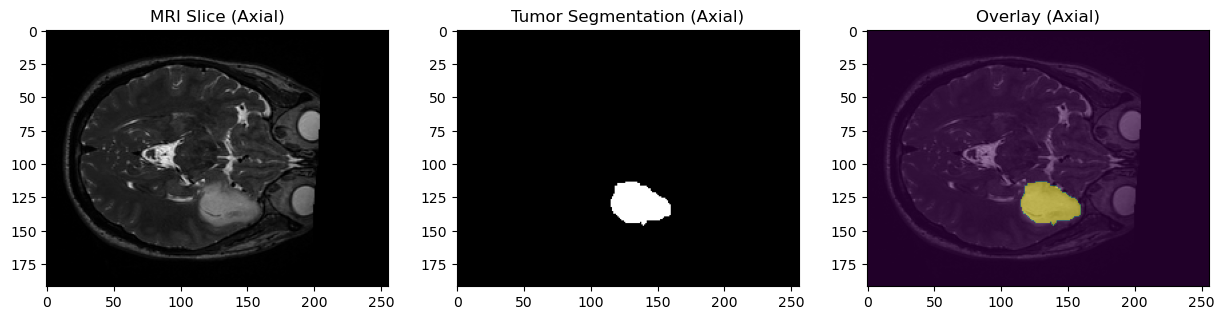

In [669]:
# Choose a sample patient identifier, here the first one for demonstration
sample_pid = 'ReMIND_001'

# Construct the file paths for the preprocessed MRI and tumor segmentation
sample_mri_path = os.path.join(imagesTr, f'{sample_pid}_0000.nii.gz')
sample_tumor_path = os.path.join(labelsTr, f'{sample_pid}.nii.gz')

mri_img = nib.load(sample_mri_path)
seg_img = nib.load(sample_tumor_path)

# Load and orient both the MRI and the segmentation using preprocessed data
mri_data = load_nifti_in_RAS(mri_img)
segmentation_data = load_nifti_in_RAS(seg_img)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = mri_data.shape[2] // 2  # adjust as necessary

# Create subplots for visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['MRI Slice (Axial)', 'Tumor Segmentation (Axial)', 'Overlay (Axial)']

# Plot MRI Slice (Axial)
axes[0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1].set_title(titles[1])

# Plot Overlay (Axial)
axes[2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[2].set_title(titles[2])

# Display the plots
plt.show()


### Labels

In [674]:
import os
import nibabel as nib

# List to hold unique labels across all segmentations
all_labels = set()
all_seg_files = set()

# Loop through each file and extract unique labels
for seg_file in os.listdir(labelsTr):
    if seg_file.endswith(".nii.gz"):  # adjust this condition based on your file types
        seg_path = os.path.join(labelsTr, seg_file)
        segmentation = nib.load(seg_path)
        seg_data = segmentation.get_fdata()
        #all_seg_files = all_seg_files.union({seg_file})
        unique_labels = set(np.unique(seg_data))  # Extract unique labels
        all_labels = all_labels.union(unique_labels)
        if len(unique_labels) > 2:
            print(seg_file, unique_labels)

# Print all unique labels found across all segmentations
print("Unique Labels across all segmentations:", all_labels)
print("Unique Labels across all segmentations:", all_seg_files)


ReMIND_005.nii.gz {0.0, 134.0, 14.0, 176.0, 255.0}
ReMIND_078.nii.gz {0.0, 255.0, 128.0, 15.0}
ReMIND_031.nii.gz {0.0, 248.0, 255.0}
ReMIND_052.nii.gz {0.0, 33.0, 255.0}
ReMIND_044.nii.gz {0.0, 252.0, 255.0}
ReMIND_020.nii.gz {0.0, 1.0, 103.0, 71.0, 20.0, 255.0}
ReMIND_098.nii.gz {0.0, 1.0, 255.0}
ReMIND_092.nii.gz {0.0, 1.0, 36.0, 180.0, 184.0, 255.0}
ReMIND_002.nii.gz {0.0, 1.0, 255.0}
ReMIND_012.nii.gz {0.0, 224.0, 255.0, 7.0}
Unique Labels across all segmentations: {0.0, 128.0, 1.0, 134.0, 71.0, 7.0, 14.0, 15.0, 20.0, 184.0, 224.0, 33.0, 36.0, 103.0, 176.0, 180.0, 248.0, 252.0, 255.0}
Unique Labels across all segmentations: set()


{0.0, 134.0, 14.0, 176.0, 255.0}


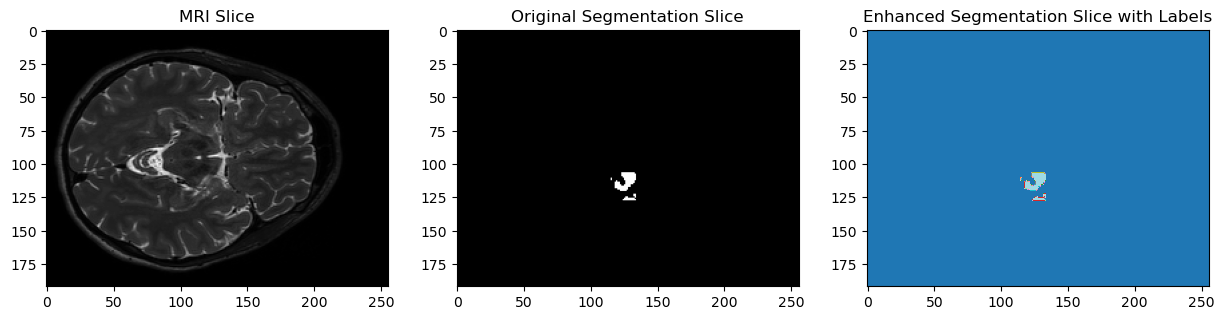

In [671]:
import matplotlib.pyplot as plt
import nibabel as nib

# Choose a sample patient identifier, here the first one for demonstration
sample_pid = 'ReMIND_005'

# Construct the file paths for the preprocessed MRI and tumor segmentation
img_path = os.path.join(imagesTr, f'{sample_pid}_0000.nii.gz')
seg_path = os.path.join(labelsTr, f'{sample_pid}.nii.gz')

img = nib.load(img_path)
seg = nib.load(seg_path)

img_data = img.get_fdata()
seg_data = seg.get_fdata()

# Choose a slice number to visualize
slice_num = img_data.shape[2] // 2  # Middle slice
slice_num = 150
# Display the MRI and segmentation side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
unique_labels = set(np.unique(seg_data)) 
print(unique_labels)
# Show original MRI slice
axes[0].imshow(img_data[:, :, slice_num], cmap='gray')
axes[0].set_title('MRI Slice')

# Show original Segmentation slice
axes[1].imshow(seg_data[:, :, slice_num], cmap='gray')
axes[1].set_title('Original Segmentation Slice')

# Enhanced visualization of Segmentation slice with labels
# The 'tab20' colormap is good for displaying up to 20 distinct labels
axes[2].imshow(seg_data[:, :, slice_num], cmap='tab20')
axes[2].set_title('Enhanced Segmentation Slice with Labels')

plt.show()


clean the labels

In [508]:
for index, row in metadata_cleaned.iterrows():
    # Check if the row corresponds to an MRI file    
    # if modality = 'SEG' then path = 'labelsTr' else path = 'imagesTr'
    if row['Modality'] == 'SEG':
        seg_file = row['new_file_name'] + '.nii.gz'
        seg_path = os.path.join(labelsTr, seg_file)
        seg_img = nib.load(seg_path)
        seg_data = seg_img.get_fdata()

        # Modify the labels in the segmentation
        seg_data_modified = np.where(np.logical_and(seg_data != 0, seg_data != 255), 0, seg_data)
        seg_data_modified[seg_data_modified > 139] = 1

        # Save the modified segmentation
        new_img = nib.Nifti1Image(seg_data_modified, affine=seg_img.affine)
        nib.save(new_img, seg_path)


In [509]:
import os
import nibabel as nib

# List to hold unique labels across all segmentations
all_labels = set()
all_seg_files = set()


# Loop through each file and extract unique labels
for seg_file in os.listdir(labelsTr):
    if seg_file.endswith(".nii.gz"):  # adjust this condition based on your file types
        seg_path = os.path.join(labelsTr, seg_file)
        segmentation = nib.load(seg_path)
        seg_data = segmentation.get_fdata()
        #all_seg_files = all_seg_files.union({seg_file})
        unique_labels = set(np.unique(seg_data))  # Extract unique labels
        all_labels = all_labels.union(unique_labels)
        if len(unique_labels) > 2:
            print(seg_file, unique_labels)

# Print all unique labels found across all segmentations
print("Unique Labels across all segmentations:", all_labels)
print("Unique Labels across all segmentations:", all_seg_files)


Unique Labels across all segmentations: {0.0, 1.0}
Unique Labels across all segmentations: set()


### create dataset json

In [410]:
import json

modality_mapping = {
    "0": "T2_SPACE",
    "1": "FLAIR",
    "2": "T2",
    "3": "T1",
    "4": "T1ce"
}
labels = {"background" : 0, "tumor" : 1}  # Define all your labels


#numTraining = len(training_cases)  # Replace with your number of training images
#print number of patients in metadata
print("Number of patients:", len(metadata_cleaned['Subject ID'].unique()))
numTraining = len(metadata_cleaned['Subject ID'].unique())

dataset_dict = { 
    "channel_names": modality_mapping
    , "labels": labels
    ,"numTraining": numTraining, 
    "file_ending": ".nii.gz"
}

# Define the path for your dataset.json file
dataset_json_path = os.path.join(dataset_dir, 'dataset.json')

# Writing the JSON structure to a file
with open(dataset_json_path, 'w') as outfile:
    json.dump(dataset_dict, outfile, indent=4)


Number of patients: 113


In [510]:
%%bash
export nnUNet_raw="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw"
export nnUNet_preprocessed="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_preprocessed"
export nnUNet_results="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_results"
echo ${nnUNet_raw}


nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity

/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw
Fingerprint extraction...
Dataset001-REMIND
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Error: Unexpected number of modalities. 
Expected: 5. 
Got: 1. 
Images: ['/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_009_0002.nii.gz']

Error: Unexpected number of modalities. 
Expected: 5. 
Got: 1. 
Images: ['/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_017_0004.nii.gz']

Error: Unexpected number of modalities. 
Expected: 5. 
Got: 1. 
Images: ['/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw/Dataset001-REMIND/imagesTr/ReMIND_029_0004.nii.gz']

Error: Unexpected number of modalities. 
Expected: 5. 
Got: 1. 
Images: ['/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentatio

Traceback (most recent call last):
  File "/Users/mervetaskaya/anaconda3/bin/nnUNetv2_plan_and_preprocess", line 8, in <module>
    sys.exit(plan_and_preprocess_entry())
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mervetaskaya/anaconda3/lib/python3.11/site-packages/nnunetv2/experiment_planning/plan_and_preprocess_entrypoints.py", line 182, in plan_and_preprocess_entry
    extract_fingerprints(args.d, args.fpe, args.npfp, args.verify_dataset_integrity, args.clean, args.verbose)
  File "/Users/mervetaskaya/anaconda3/lib/python3.11/site-packages/nnunetv2/experiment_planning/plan_and_preprocess_api.py", line 47, in extract_fingerprints
    extract_fingerprint_dataset(d, fingerprint_extractor_class, num_processes, check_dataset_integrity, clean,
  File "/Users/mervetaskaya/anaconda3/lib/python3.11/site-packages/nnunetv2/experiment_planning/plan_and_preprocess_api.py", line 30, in extract_fingerprint_dataset
    verify_dataset_integrity(join(nnUNet_raw, dataset_name), num_process

CalledProcessError: Command 'b'export nnUNet_raw="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw"\nexport nnUNet_preprocessed="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_preprocessed"\nexport nnUNet_results="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_results"\necho ${nnUNet_raw}\n\n\nnnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity\n'' returned non-zero exit status 1.

As all other files were removed because the shapes of each files (T1, T2, ..) are not fitting, the modalities will not be used anymore as we only have 1 File per image. So the modalitiy is changing to one (0 : MR) and the files has to be also renamed.

In [516]:
#replace the last 4 digits of all files in imagesTr with 0000 in python
import os

for filename in os.listdir(imagesTr):
    if filename.endswith(".nii.gz"):
        os.rename(os.path.join(imagesTr, filename), os.path.join(imagesTr, filename[:-8] + '0.nii.gz'))
        print(filename[:-8])
        continue
    else:
        continue


ReMIND_079_000
ReMIND_084_000
ReMIND_003_000
ReMIND_058_000
ReMIND_057_000
ReMIND_041_000
ReMIND_107_000
ReMIND_015_000
ReMIND_112_000
ReMIND_070_000
ReMIND_024_000
ReMIND_077_000
ReMIND_054_000
ReMIND_096_000
ReMIND_066_000
ReMIND_101_000
ReMIND_051_000
ReMIND_021_000
ReMIND_075_000
ReMIND_040_000
ReMIND_047_000
ReMIND_037_000
ReMIND_052_000
ReMIND_022_000
ReMIND_081_000
ReMIND_006_000
ReMIND_055_000
ReMIND_114_000
ReMIND_010_000
ReMIND_102_000
ReMIND_013_000
ReMIND_063_000
ReMIND_026_000
ReMIND_023_000
ReMIND_005_000
ReMIND_082_000
ReMIND_078_000
ReMIND_034_000
ReMIND_097_000
ReMIND_009_000
ReMIND_028_000
ReMIND_065_000
ReMIND_060_000
ReMIND_046_000
ReMIND_033_000
ReMIND_092_000
ReMIND_031_000
ReMIND_027_000
ReMIND_073_000
ReMIND_019_000
ReMIND_104_000
ReMIND_091_000
ReMIND_016_000
ReMIND_038_000
ReMIND_088_000
ReMIND_103_000
ReMIND_061_000
ReMIND_048_000
ReMIND_045_000
ReMIND_018_000
ReMIND_100_000
ReMIND_044_000
ReMIND_068_000
ReMIND_012_000
ReMIND_036_000
ReMIND_111_000
ReMIND_089

In [517]:
import json

modality_mapping = {
    "0": "MR"
}
labels = {"background" : 0, "tumor" : 1}  # Define all your labels


#numTraining = len(training_cases)  # Replace with your number of training images
#print number of patients in metadata
print("Number of patients:", len(metadata_cleaned['Subject ID'].unique()))
numTraining = len(metadata_cleaned['Subject ID'].unique())

dataset_dict = { 
    "channel_names": modality_mapping
    , "labels": labels
    ,"numTraining": numTraining, 
    "file_ending": ".nii.gz"
}

# Define the path for your dataset.json file
dataset_json_path = os.path.join(dataset_dir, 'dataset.json')

# Writing the JSON structure to a file
with open(dataset_json_path, 'w') as outfile:
    json.dump(dataset_dict, outfile, indent=4)


Number of patients: 113


In [518]:
%%bash
export nnUNet_raw="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw"
export nnUNet_preprocessed="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_preprocessed"
export nnUNet_results="/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_results"
echo ${nnUNet_raw}


nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity

/Users/mervetaskaya/Documents/MED_Project/braintumorsegmentation/data/nnunet/nnunet_raw
Fingerprint extraction...
Dataset001-REMIND
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer


100%|██████████| 113/113 [00:12<00:00,  8.86it/s]


Experiment planning...
Attempting to find 3d_lowres config. 
Current spacing: [1.03 1.03 1.03]. 
Current patch size: [112 160 128]. 
Current median shape: [186.40776699 246.60194175 196.11650485]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 57, 'patch_size': array([256, 224]), 'median_image_size_in_voxels': array([254., 202.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': (2, 2, 2, 2, 2, 2), 'n_conv_per_stage_decoder': (2, 2, 2, 2, 2), 'num_pool_per_axis': [5, 5], 'pool_op_kernel_sizes': [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]], 'conv_kernel_sizes': [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]], 'unet_max_num_features': 512, 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_

100%|██████████| 113/113 [00:35<00:00,  3.14it/s]


Configuration: 3d_fullres...


100%|██████████| 113/113 [01:02<00:00,  1.79it/s]


Configuration: 3d_lowres...


100%|██████████| 113/113 [01:53<00:00,  1.00s/it]


Create Test Data Set out of the tumor files which was removed because there was already one for one patient. 

In [562]:
metadata3 = metadata[(metadata['Study Description'] == 'Preop')]
metadata3 = metadata3[(metadata3['Modality'] == 'SEG') & (metadata3['Series Description'].str.contains('tumor seg'))]
metadata3 = metadata3[metadata3['Subject ID'].isin(metadata_cleaned['Subject ID'])]

difference = metadata3.merge(metadata_cleaned, 
                           on=['Series Description', 'Subject ID'], 
                           how='left', 
                           indicator=True).loc[lambda x : x['_merge']=='left_only']
difference

,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality_x,SOP Class Name,SOP Class UID,Number of Images,Number of ?,File Size,File Location_x,Download Timestamp,Modality_y,File Location_y,Mapped_Label_v2,MRI_Ref,Flagged_for_Segmentation,Mapped_Label,new_file_name,FullFilePath,_merge
2,1.3.6.1.4.1.14519.5.2.1.80716149485382078399551532220853537216,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-002,1.3.6.1.4.1.14519.5.2.1.322752919633473126929523630915804178948,Preop,12-25-1982,tumor seg - MR ref 3DAXT1postcontrast,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,17,15 KB,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/303.000000-tumor seg - MR ref 3DAXT1postcontrast-37216,2023-12-11T17:26:36.683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
5,1.3.6.1.4.1.14519.5.2.1.27661008822762431370973483522020876264,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-004,1.3.6.1.4.1.14519.5.2.1.21953915370182127679153341817124092346,Preop,12-25-1982,tumor seg - MR ref 3DAXT1postcontrast,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,4,19 KB,./ReMIND/ReMIND-004/12-25-1982-NA-Preop-92346/303.000000-tumor seg - MR ref 3DAXT1postcontrast-76264,2023-12-11T17:27:32.557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
14,1.3.6.1.4.1.14519.5.2.1.47781733328041466675295451070775439319,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-012,1.3.6.1.4.1.14519.5.2.1.152784448342162743096935191880249421828,Preop,12-25-1982,tumor seg - MR ref 3DSAGT2FLAIR,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,16,39 KB,./ReMIND/ReMIND-012/12-25-1982-NA-Preop-21828/303.000000-tumor seg - MR ref 3DSAGT2FLAIR-39319,2023-12-11T17:31:44.812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
46,1.3.6.1.4.1.14519.5.2.1.67243699569043447143476825892207208908,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-045,1.3.6.1.4.1.14519.5.2.1.330598436915637380361214472225052069640,Preop,12-25-1982,tumor seg - MR ref 3DAXT1postcontrast,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,22,52 KB,./ReMIND/ReMIND-045/12-25-1982-NA-Preop-69640/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08908,2023-12-11T17:50:34.664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
58,1.3.6.1.4.1.14519.5.2.1.234103760339188915153229936779015926100,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-055,1.3.6.1.4.1.14519.5.2.1.242689172419883809812181800794836739997,Preop,12-25-1982,tumor seg - MR ref 3DAXT1postcontrast,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,9,56 KB,./ReMIND/ReMIND-055/12-25-1982-NA-Preop-39997/303.000000-tumor seg - MR ref 3DAXT1postcontrast-26100,2023-12-11T17:56:32.276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
64,1.3.6.1.4.1.14519.5.2.1.279202455830252440218326189567042952282,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-060,1.3.6.1.4.1.14519.5.2.1.30394276724623621940870519878827102294,Preop,12-25-1982,tumor seg - MR ref 3DAXT1postcontrast,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,23,16 KB,./ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/303.000000-tumor seg - MR ref 3DAXT1postcontrast-52282,2023-12-11T18:00:42.148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
70,1.3.6.1.4.1.14519.5.2.1.188200387530081972563152984731936153871,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-066,1.3.6.1.4.1.14519.5.2.1.74266087281706948184425796375594396891,Preop,12-25-1982,tumor seg - MR ref 3DSAGT1MP2RAGE,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,29,60 KB,./ReMIND/ReMIND-066/12-25-1982-NA-Preop-96891/303.000000-tumor seg - MR ref 3DSAGT1MP2RAGE-53871,2023-12-11T18:03:33.441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
72,1.3.6.1.4.1.14519.5.2.1.334249337994962158775827368341420231119,ReMIND,NO,https://doi.org/10.7937/3RAGD070,ReMIND-067,1.3.6.1.4.1.14519.5.2.1.286185830392102553489015311815092377145,Preop,12-25-1982,tumor seg - MR ref 3DAXT1postcontrast,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,1

In [563]:
#just keep Subject ID and Modality, Series Description, File Location
difference = difference[['Subject ID', 'Modality_x', 'Series Description', 'File Location_x']]

#rename columns 
difference = difference.rename(columns={"Modality_x": "Modality", "File Location_x": "File Location"})

difference



,Subject ID,Modality,Series Description,File Location
2,ReMIND-002,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/303.000000-tumor seg - MR ref 3DAXT1postcontrast-37216
5,ReMIND-004,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-004/12-25-1982-NA-Preop-92346/303.000000-tumor seg - MR ref 3DAXT1postcontrast-76264
14,ReMIND-012,SEG,tumor seg - MR ref 3DSAGT2FLAIR,./ReMIND/ReMIND-012/12-25-1982-NA-Preop-21828/303.000000-tumor seg - MR ref 3DSAGT2FLAIR-39319
46,ReMIND-045,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-045/12-25-1982-NA-Preop-69640/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08908
58,ReMIND-055,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-055/12-25-1982-NA-Preop-39997/303.000000-tumor seg - MR ref 3DAXT1postcontrast-26100
64,ReMIND-060,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/303.000000-tumor seg - MR ref 3DAXT1postcontrast-52282
70,ReMIND-066,SEG,tumor seg - MR ref 3DSAGT1MP2RAGE,./ReMIND/ReMIND-066/12-25-1982-NA-Preop-96891/303.000000-tumor seg - MR ref 3DSAGT1MP2RAGE-53871
72,ReMIND-067,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-067/12-25-1982-NA-Preop-77145/303.000000-tumor seg - MR ref 3DAXT1postcontrast-31119
81,ReMIND-074,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-074/12-25-1982-NA-Preop-89000/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08532
84,ReMIND-077,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-077/12-25-1982-NA-Preop-68266/303.000000-tumor seg - MR ref 3DAXT1postcontrast-98945


In [581]:
# show the MRI Reference for the segmentation
difference['MRI_Ref'] = difference['Series Description'].apply(extract_mri_reference)

#look for the MRI_REF and Subject ID as key in metadata without join and Modality = MR
metadata4 = metadata[(metadata['Modality'] == 'MR') & (metadata['Study Description'] == 'Preop') & ((metadata['Series Description'].isin(difference['MRI_Ref'])) & (metadata['Subject ID'].isin(difference['Subject ID'])))].copy()

#crete column MRI_Ref in metadata4 with Series Description
metadata4.loc[:, 'MRI_Ref'] = metadata4['Series Description']

#inner join metadata4 and difference on Subject ID = Subject ID and MRI_Ref = Series Description
metadata4 = metadata4.merge(difference, 
                           on=['Subject ID', 'MRI_Ref'], 
                           how='inner', 
                           indicator=True).loc[lambda x : x['_merge']=='both']

#just keep Subject ID and Modality, Series Description, File Location
metadata4 = metadata4[['Subject ID', 'Modality_x', 'Series Description_x', 'File Location_x']]
#rename columns
metadata4 = metadata4.rename(columns={"Modality_x": "Modality", "Series Description_x": "Series Description", "File Location_x": "File Location"})

#add metadata4 to difference
difference = pd.concat([difference, metadata4])


In [676]:
difference

,Subject ID,Modality,Series Description,File Location,MRI_Ref,FullFilePath
2,ReMIND-002,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/303.000000-tumor seg - MR ref 3DAXT1postcontrast-37216,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-002/12-25-1982-NA-Preop-78948/303.000000-tumor seg - MR ref 3DAXT1postcontrast-37216
5,ReMIND-004,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-004/12-25-1982-NA-Preop-92346/303.000000-tumor seg - MR ref 3DAXT1postcontrast-76264,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-004/12-25-1982-NA-Preop-92346/303.000000-tumor seg - MR ref 3DAXT1postcontrast-76264
14,ReMIND-012,SEG,tumor seg - MR ref 3DSAGT2FLAIR,./ReMIND/ReMIND-012/12-25-1982-NA-Preop-21828/303.000000-tumor seg - MR ref 3DSAGT2FLAIR-39319,3DSAGT2FLAIR,data/data_selected/ReMIND/ReMIND-012/12-25-1982-NA-Preop-21828/303.000000-tumor seg - MR ref 3DSAGT2FLAIR-39319
46,ReMIND-045,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-045/12-25-1982-NA-Preop-69640/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08908,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-045/12-25-1982-NA-Preop-69640/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08908
58,ReMIND-055,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-055/12-25-1982-NA-Preop-39997/303.000000-tumor seg - MR ref 3DAXT1postcontrast-26100,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-055/12-25-1982-NA-Preop-39997/303.000000-tumor seg - MR ref 3DAXT1postcontrast-26100
64,ReMIND-060,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/303.000000-tumor seg - MR ref 3DAXT1postcontrast-52282,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-060/12-25-1982-NA-Preop-02294/303.000000-tumor seg - MR ref 3DAXT1postcontrast-52282
70,ReMIND-066,SEG,tumor seg - MR ref 3DSAGT1MP2RAGE,./ReMIND/ReMIND-066/12-25-1982-NA-Preop-96891/303.000000-tumor seg - MR ref 3DSAGT1MP2RAGE-53871,3DSAGT1MP2RAGE,data/data_selected/ReMIND/ReMIND-066/12-25-1982-NA-Preop-96891/303.000000-tumor seg - MR ref 3DSAGT1MP2RAGE-53871
72,ReMIND-067,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-067/12-25-1982-NA-Preop-77145/303.000000-tumor seg - MR ref 3DAXT1postcontrast-31119,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-067/12-25-1982-NA-Preop-77145/303.000000-tumor seg - MR ref 3DAXT1postcontrast-31119
81,ReMIND-074,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-074/12-25-1982-NA-Preop-89000/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08532,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-074/12-25-1982-NA-Preop-89000/303.000000-tumor seg - MR ref 3DAXT1postcontrast-08532
84,ReMIND-077,SEG,tumor seg - MR ref 3DAXT1postcontrast,./ReMIND/ReMIND-077/12-25-1982-NA-Preop-68266/303.000000-tumor seg - MR ref 3DAXT1postcontrast-98945,3DAXT1postcontrast,data/data_selected/ReMIND/ReMIND-077/12-25-1982-NA-Preop-68266/303.000000-tumor seg - MR ref 3DAXT1postcontrast-98945


In [582]:
# Adjusting FullFilePath construction
difference['FullFilePath'] = difference['File Location'].apply(lambda x: os.path.join(root_path, x[2:]))


In [586]:
# Process and save MRI files
for index, row in difference.iterrows():
    # Check if the row corresponds to an MRI file
    if row['Modality'] != 'SEG':
        image_dir = row['FullFilePath']
        original_file_name = row['Subject ID'].replace('-', '_') + '_0000.nii.gz'

        # Convert MRI to NIfTI and save
        nifti_img = dicom2nifti(image_dir, imagesTs, save=False)

        # Write the converted MRI image
        original_nii_path = os.path.join(imagesTs, original_file_name)
        sitk.WriteImage(nifti_img, original_nii_path)
        print(f"Saved original MRI: {original_file_name}")



ImageSeriesReader (0x2b7e346f0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000722401



Saved original MRI: ReMIND_002_0000.nii.gz


ImageSeriesReader (0x3384074d0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00869027



Saved original MRI: ReMIND_004_0000.nii.gz
Saved original MRI: ReMIND_012_0000.nii.gz


ImageSeriesReader (0x33aa0e4d0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000811001



...

Saved original MRI: ReMIND_077_0000.nii.gz


ImageSeriesReader (0x2a6676390): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000729428



Saved original MRI: ReMIND_078_0000.nii.gz
Saved original MRI: ReMIND_085_0000.nii.gz
Saved original MRI: ReMIND_092_0000.nii.gz


ImageSeriesReader (0x14288cfb0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00065375



Saved original MRI: ReMIND_097_0000.nii.gz


In [587]:
labelsTs = os.path.join(dataset_dir, 'labelsTs')
os.makedirs(labelsTs, exist_ok=True)

In [675]:
# check in metadata the indices_to_remove
#create folder in data/nnunet/nnunet_raw/labelsTs

# Process and save segmentation files
for index, row in difference.iterrows():
    # Check if the row corresponds to a segmentation file
    seg_file_name = row['Subject ID'].replace('-', '_') + '.nii'
    mri_file_name = row['Subject ID'].replace('-', '_') + '_0000.nii'
    if row['Modality'] == 'SEG':
        image_dir = labelsTs
        seg_file = row['FullFilePath']

        # Convert MRI to NIfTI and save
        nifti_img = dicom2nifti_segmentation(seg_file, labelsTs, save=False)
        sitk.WriteImage(nifti_img, os.path.join(labelsTs, seg_file_name))


        # Load the corresponding MRI
        mri_image = sitk.ReadImage(os.path.join(imagesTs, row['Subject ID'].replace('-', '_') + '_0000.nii'))  # Implement this function based on your data
        segmentation_image = sitk.ReadImage(os.path.join(labelsTs, seg_file_name))
        if mri_image:  # Proceed if a corresponding MRI was found
            # Convert segmentation to NIfTI
            resampling_img = resampling(mri_image, segmentation_image, os.path.join(labelsTr, seg_file_name))
            sitk.WriteImage(resampling_img, os.path.join(labelsTs, seg_file_name))
        else:
            print(f"No corresponding MRI found for segmentation: {seg_file_name}")
        
   
    # if modality = 'SEG' then path = 'labelsTr' else path = 'imagesTr'
    if row['Modality'] == 'SEG':
        image_dir = labelsTs
        original_file_name = seg_file_name
    else:
        image_dir = imagesTs
        original_file_name = mri_file_name

    nifti_img = nib.load(os.path.join(image_dir, original_file_name))
    # Convert MRI to NIfTI and save
    nifti_data = load_nifti_in_RAS(nifti_img)

    new_nii_img = nib.Nifti1Image(nifti_data, affine=np.eye(4))
    nib.save(new_nii_img, os.path.join(image_dir, new_file_name))

